In [23]:
from ratansunpy.client import RATANClient
from ratansunpy.utils import get_project_root
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from ratansunpy.core.ar_handling import ARHandler

In [3]:
processed_path = get_project_root()/"data"/"20170905_121217_sun+0_out_processed.fits"
raw_path = get_project_root()/"data"/"20170905_121217_sun+0_out.fits"
processed_hdul = fits.open(processed_path)
raw_hdul = fits.open(raw_path)

In [4]:
base_path = get_project_root()/"data"
base_url = str(base_path) + '/%Y_SRS/%Y%m%dSRS.txt'
ratan_client = RATANClient()
srs_table = ratan_client.form_srstable_with_time_shift(processed_hdul, base_url)

/Users/irinaknyazeva/Yandex.Disk.localized/Projects/RadioSun/venv/lib/python3.10/site-packages/numpy/ma/core.py:467: RuntimeWarning: invalid value encountered in cast
  fill_value = np.array(fill_value, copy=False, dtype=ndtype)


In [5]:
srs_table

Date,ID,Number,Carrington Longitude,Area,Z,Longitudinal Extent,Number of Sunspots,Mag Type,Latitude,Longitude,RatanTime
str10,str2,int64,int64,int64,str3,int64,int64,str16,float64,float64,str16
2017-09-05,I,2673,119,680,Dkc,7,28,Beta-Gamma-Delta,408.69101889567594,-98.01836659801228,2017/09/05 09:12
2017-09-05,I,2674,104,740,Fhi,18,34,Beta,47.36041326137899,143.00174423677404,2017/09/05 09:12
2017-09-05,I,2675,179,10,Bxo,5,4,Beta,900.4670848300949,309.2825831307679,2017/09/05 09:12
2017-09-05,I,2676,168,30,Cro,8,4,Beta,899.7829666555876,160.02607015230404,2017/09/05 09:12
2017-09-05,I,2677,52,10,Axx,1,2,Alpha,-683.2804279668718,-28.803008992661006,2017/09/05 09:12


In [6]:
handler = ARHandler(processed_hdul, srs_base_url=base_url)

In [8]:

ar_2673 = handler.extract_ar_data_with_window(latitude=408.69)
mask_2673 = handler.compute_ar_mask(ar_2673)


Text(0.5, 1.0, 'Mask value across FREQ')

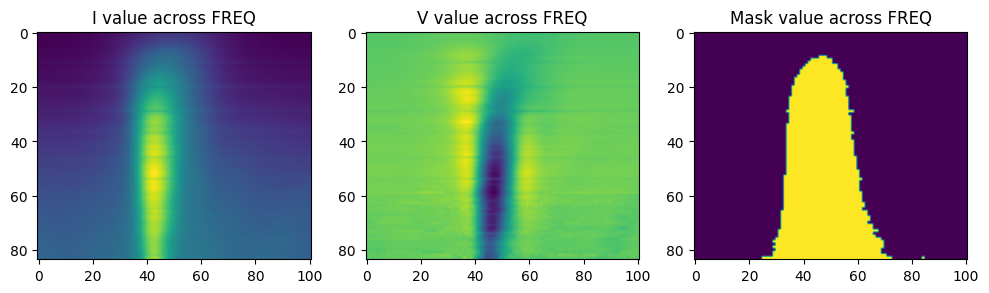

In [15]:
plt.figure(figsize=(12,5))
plt.subplot(131); plt.imshow(ar_2673[0]); plt.title("I value across FREQ")
plt.subplot(132); plt.imshow(ar_2673[1]); plt.title("V value across FREQ")
plt.subplot(133); plt.imshow(mask_2673); plt.title("Mask value across FREQ")



In [30]:
#вот так например можно посчитать площади
np.sum(np.ma.masked_equal((ar_2673*mask_2673), 0)[0], axis=1).data

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.71755527,
        1.99858566,  2.21887827,  3.08230472,  3.47851674,  4.14633018,
        4.56393117,  5.01199712,  5.45706464,  5.89142489,  6.10041055,
        6.50349417,  6.52649848,  6.77286838,  6.97623622,  7.66953364,
        7.87834674,  8.04461309,  8.20685707,  8.41079895,  8.98531905,
        8.62699717,  9.23886649,  9.35258725,  9.50754949,  9.63441201,
        9.66690862,  9.77846658,  9.82768565,  9.95184444, 10.14799087,
       10.3490776 , 10.34640947, 10.65788518, 10.58563232, 10.7372417 ,
       10.78375995, 10.63828099, 10.82988386, 10.90132773, 11.08622022,
       11.08931433, 11.44597733, 11.5215895 , 11.62500642, 11.63443567,
       11.62118684, 11.47708815, 11.61073731, 11.45043251, 11.57924427,
       11.41128699, 11.45286165, 11.31551263, 11.50830357, 11.45197697,
       11.07611047, 12.03700906, 11.78645971, 12.24185897, 12.10

(101,)